In [1]:
%store -r ITCZ_shift_all_2071_2100
%store -r ITCZ_shift_all_2021_2050
%store -r TS_hemispheric_2071_2100
%store -r TS_hemispheric_2021_2050

In [2]:
TS_hemispheric_2071_2100

<xarray.DataArray 'TS_NH_minus_SH' (experiment: 2, model: 5)> Size: 80B
array([[ 0.00110258,  0.03870781,  0.65761957, -0.37737835,  0.01171144],
       [ 0.02757113,  0.04419711,  0.52012857, -0.09094599,  0.01195722]])
Coordinates:
  * experiment  (experiment) <U15 120B 'G6sulfur-SSP245' 'G6solar-SSP245'
  * model       (model) <U13 260B 'UKESM1-0-LL' 'CNRM-ESM2-1' ... 'IPSL-CM6A-LR'

In [3]:
TS_hemispheric_2021_2050

<xarray.DataArray 'TS_NH_minus_SH' (experiment: 2, model: 5)> Size: 80B
array([[ 0.06414392,  0.23811755,  0.57205916, -0.18111016, -0.04052087],
       [ 0.05203931,  0.09035499,  0.39926054,  0.05705994, -0.11014958]])
Coordinates:
  * experiment  (experiment) <U15 120B 'G6sulfur-SSP245' 'G6solar-SSP245'
  * model       (model) <U13 260B 'UKESM1-0-LL' 'CNRM-ESM2-1' ... 'IPSL-CM6A-LR'

In [4]:
#Model Names

MODELS = {
    "UKESM1-0-LL":  {"institution": "MOHC",         "ensemble": "r1i1p1f2",  "grid": "gn",},
    "CNRM-ESM2-1":  {"institution": "CNRM-CERFACS", "ensemble": "r1i1p1f2",  "grid": "gr",},
    "MPI-ESM1-2-LR":{"institution": "MPI-M",        "ensemble": "r1i1p1f1",  "grid": "gn",},
    "CESM2-WACCM":  {"institution": "NCAR",         "ensemble": "r1i1p1f1",  "grid": "gn",},
    "IPSL-CM6A-LR": {"institution": "IPSL",         "ensemble": "r1i1p1f1",  "grid": "gr",},
}


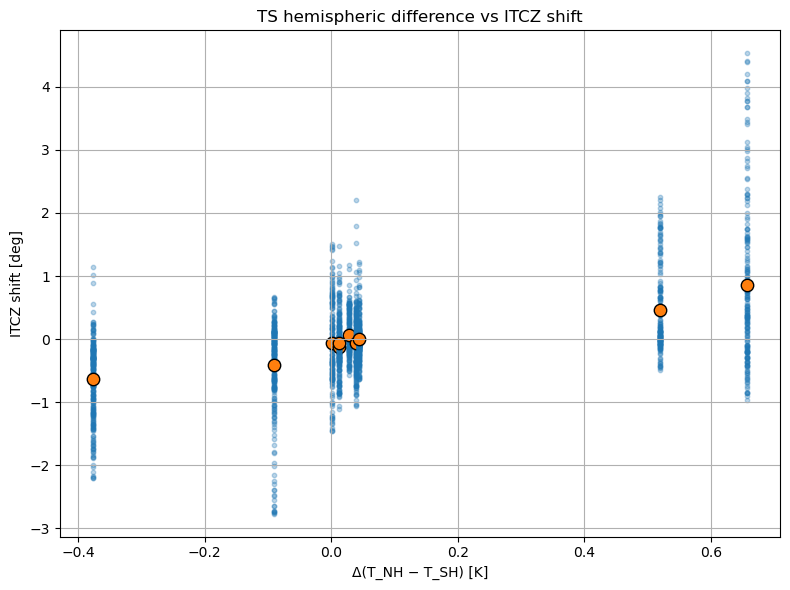

In [5]:
import matplotlib.pyplot as plt
import numpy as np

TS_hemispheric=TS_hemispheric_2071_2100

experiments = ["G6sulfur-SSP245", "G6solar-SSP245"]
models = list(MODELS.keys())

fig, ax = plt.subplots(figsize=(8,6))

for model in models:
    for exp in experiments:
        # X-axis: NH-SH temperature difference
        x = TS_hemispheric.loc[exp, model].values

        # Y-axis: ITCZ shift
        itcz_mean = ITCZ_shift_all_2071_2100[model][exp]["mean"].values      # scalar
        itcz_by_lon = ITCZ_shift_all_2071_2100[model][exp]["by_lon"].values  # array over longitude

        # Plot many faint points (longitude-resolved)
        ax.scatter(
            np.full_like(itcz_by_lon, x),  # repeat same TS value
            itcz_by_lon,
            color='C0',
            alpha=0.3,
            s=10,
            label="_nolegend_"
        )

        # Plot big dot for mean ITCZ shift
        ax.scatter(
            x, itcz_mean,
            color='C1',
            s=80,
            edgecolor='k',
            label="_nolegend_"
        )

# Labels and styling
ax.set_xlabel("Δ(T_NH − T_SH) [K]")
ax.set_ylabel("ITCZ shift [deg]")
ax.set_title("TS hemispheric difference vs ITCZ shift")
ax.grid(True)

plt.tight_layout()
plt.show()

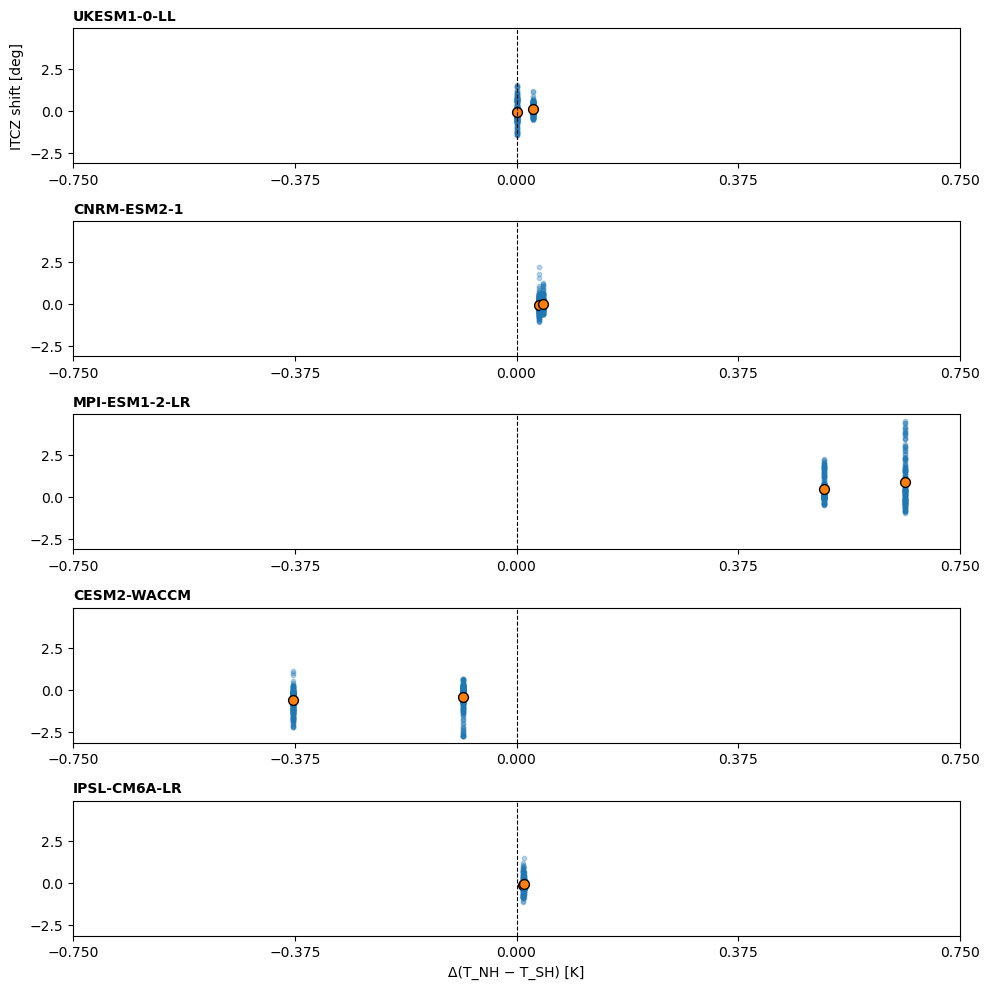

In [6]:
import matplotlib.pyplot as plt
import numpy as np

experiments = ["G6sulfur-SSP245", "G6solar-SSP245"]
models = list(MODELS.keys())

fig, axes = plt.subplots(len(models), 1, figsize=(10, 2*len(models)), sharey=True)

# Ensure axes is array
axes = np.atleast_1d(axes)

xlims = (-0.75, 0.75)  # X-axis for each model strip

for i, model in enumerate(models):
    ax = axes[i]

    for exp in experiments:
        # TS hemispheric difference
        x = TS_hemispheric.loc[exp, model].values

        # ITCZ shift
        itcz_mean = ITCZ_shift_all_2071_2100[model][exp]["mean"].values
        itcz_by_lon = ITCZ_shift_all_2071_2100[model][exp]["by_lon"].values

        # Longitude-resolved points
        ax.scatter(
            np.full_like(itcz_by_lon, x),  # same TS for all longitudes
            itcz_by_lon,
            color='C0',
            alpha=0.3,
            s=10,
            label="_nolegend_"
        )

        # Mean ITCZ shift
        ax.scatter(
            x, itcz_mean,
            color='C1',
            s=50,
            edgecolor='k',
            label="_nolegend_"
        )

    # Strip labeling
    ax.set_title(model, fontsize=10, loc='left', fontweight='bold')

    # Strip x-limits
    ax.set_xlim(xlims)

    # Vertical line at 0 for reference
    ax.axvline(0, color='k', linewidth=0.8, linestyle='--')

    # Only show x-ticks
    ax.set_xticks(np.linspace(xlims[0], xlims[1], 5))

# Y-axis shared across strips
axes[0].set_ylabel("ITCZ shift [deg]")

# X-axis label only for bottom strip
axes[-1].set_xlabel("Δ(T_NH − T_SH) [K]")

plt.tight_layout()
plt.show()

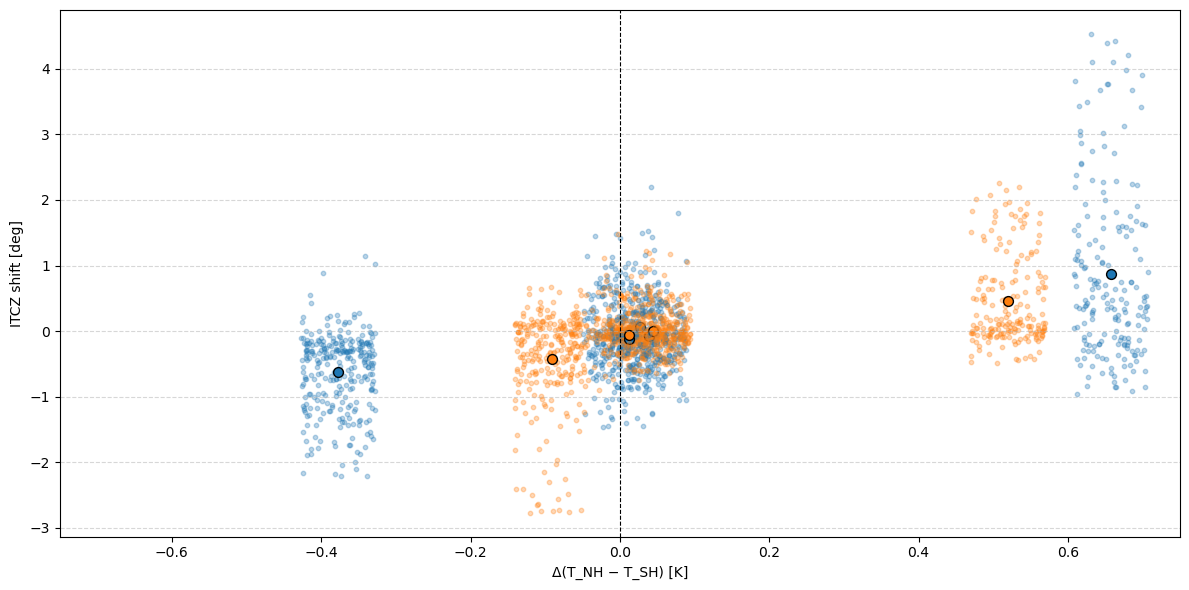

In [7]:
import matplotlib.pyplot as plt
import numpy as np

experiments = ["G6sulfur-SSP245", "G6solar-SSP245"]
models = list(MODELS.keys())

fig, ax = plt.subplots(figsize=(12, 6))

x_spread = 0.05  # spread for points within the strip

colors = {"G6sulfur-SSP245": "C0", "G6solar-SSP245": "C1"}

for i, model in enumerate(models):
    x_center = TS_hemispheric.loc[experiments[0], model].values  # center x of strip

    for exp in experiments:
        x_center = TS_hemispheric.loc[exp, model].values

        # ITCZ shift
        itcz_mean = ITCZ_shift_all_2071_2100[model][exp]["mean"].values
        itcz_by_lon = ITCZ_shift_all_2071_2100[model][exp]["by_lon"].values

        # add a tiny random jitter horizontally for points
        jitter = np.random.uniform(-x_spread, x_spread, size=itcz_by_lon.size)

        # Longitude-resolved points
        ax.scatter(
            x_center + jitter,
            itcz_by_lon,
            color=colors[exp],
            alpha=0.3,
            s=10,
            label="_nolegend_"
        )

        # Mean ITCZ shift
        ax.scatter(
            x_center, itcz_mean,
            color=colors[exp],
            s=50,
            edgecolor='k',
            label=f"{model} {exp}" if i==0 else "_nolegend_"
        )

# Reference line at x=0
ax.axvline(0, color='k', linestyle='--', linewidth=0.8)

ax.set_xlabel("Δ(T_NH − T_SH) [K]")
ax.set_ylabel("ITCZ shift [deg]")

ax.set_xlim(-0.75, 0.75)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

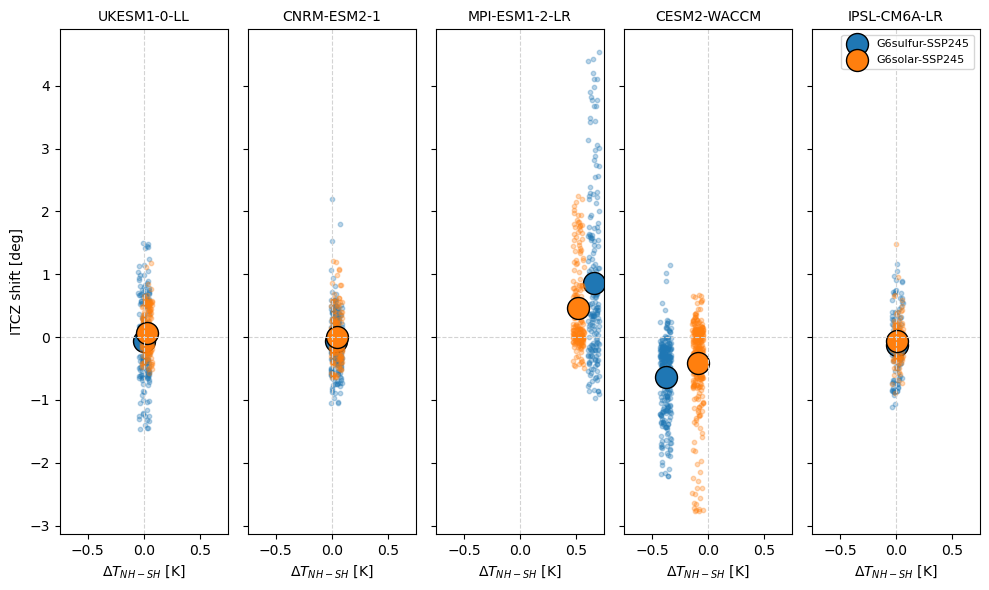

In [8]:
import matplotlib.pyplot as plt
import numpy as np
TS_hemispheric=TS_hemispheric_2071_2100

experiments = ["G6sulfur-SSP245", "G6solar-SSP245"]
models = list(MODELS.keys())

n_models = len(models)
fig, axes = plt.subplots(
    nrows=1,
    ncols=n_models,
    figsize=(2*n_models, 6),
    sharey=True
)

if n_models == 1:
    axes = [axes]  # make it iterable

x_spread = 0.05  # jitter for points within each strip
colors = {"G6sulfur-SSP245": "C0", "G6solar-SSP245": "C1"}

for ax, model in zip(axes, models):
    for exp in experiments:
        # Center x for this experiment
        x_center = TS_hemispheric.loc[exp, model].values

        # ITCZ shift
        itcz_mean = ITCZ_shift_all_2071_2100[model][exp]["mean"].values
        itcz_by_lon = ITCZ_shift_all_2071_2100[model][exp]["by_lon"].values

        # Tiny horizontal jitter so points don’t overlap exactly
        jitter = np.random.uniform(-x_spread, x_spread, size=itcz_by_lon.size)

        # Plot longitude-resolved ITCZ points
        ax.scatter(
            x_center + jitter,
            itcz_by_lon,
            color=colors[exp],
            alpha=0.3,
            s=10,
            label="_nolegend_"
        )

        # Plot mean ITCZ shift
        ax.scatter(
            x_center,
            itcz_mean,
            color=colors[exp],
            s=250,
            edgecolor='k',
            label=exp
        )

    # Reference line at x=0
    ax.axvline(0, color='lightgray', linestyle='--', linewidth=0.8)
    # Reference line at y=0
    ax.axhline(0, color='lightgray', linestyle='--', linewidth=0.8)

    # Axis settings
    ax.set_xlim(-0.75, 0.75)
    ax.set_xlabel("$ΔT_{NH − SH}$ [K]")
    ax.set_title(model, fontsize=10)
    # ax.grid(True, axis='y', linestyle='--', alpha=0.5)

axes[0].set_ylabel("ITCZ shift [deg]")
axes[-1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

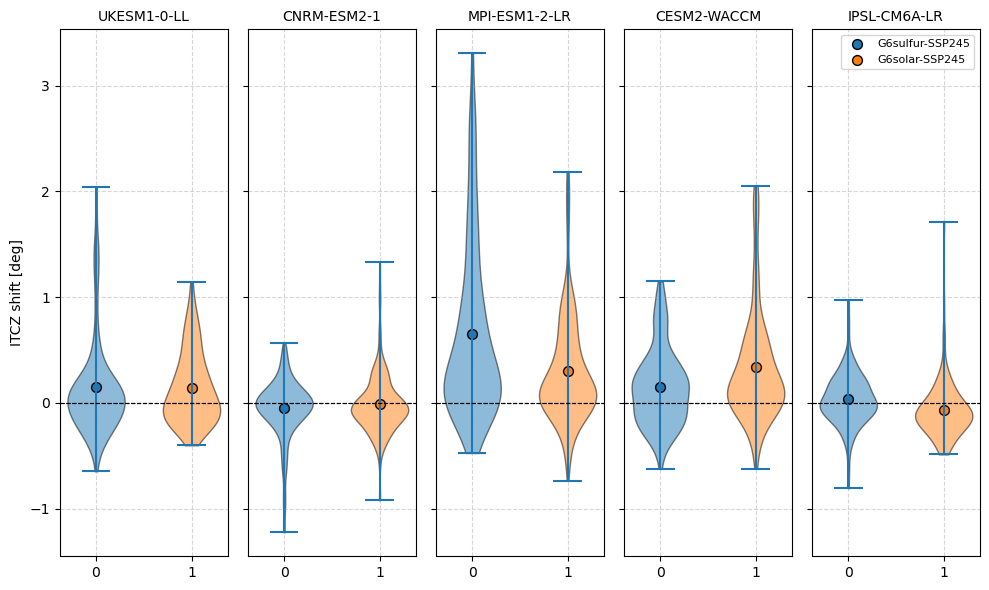

In [9]:
import matplotlib.pyplot as plt
import numpy as np

experiments = ["G6sulfur-SSP245", "G6solar-SSP245"]
models = list(MODELS.keys())

n_models = len(models)
fig, axes = plt.subplots(
    nrows=1,
    ncols=n_models,
    figsize=(2*n_models, 6),
    sharey=True
)

if n_models == 1:
    axes = [axes]  # make it iterable

colors = {"G6sulfur-SSP245": "C0", "G6solar-SSP245": "C1"}

for ax, model in zip(axes, models):
    data_to_plot = []
    positions = []
    
    for i, exp in enumerate(experiments):
        # Center x for this experiment
        x_center = TS_hemispheric.loc[exp, model].values

        # ITCZ shift
        itcz_mean = ITCZ_shift_all_2021_2050[model][exp]["mean"].values
        itcz_by_lon = ITCZ_shift_all_2021_2050[model][exp]["by_lon"].values

        # Add data to the list for violinplot
        data_to_plot.append(itcz_by_lon)
        positions.append(i)  # position for the violin

    # Plot violin plots
    vp = ax.violinplot(
        data_to_plot,
        positions=positions,
        showmeans=False,
        showmedians=False,
        widths=0.6
    )

    # Color the violins
    for i, body in enumerate(vp['bodies']):
        body.set_facecolor(colors[experiments[i]])
        body.set_alpha(0.5)
        body.set_edgecolor('k')

    # Overlay mean points
    for i, exp in enumerate(experiments):
        x_center = i
        itcz_mean = ITCZ_shift_all_2021_2050[model][exp]["mean"].values
        ax.scatter(
            x_center,
            itcz_mean,
            color=colors[exp],
            s=50,
            edgecolor='k',
            label=exp
        )

    # Reference line at x=0
    ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
    # Horizontal line at y=0
    ax.axhline(0, color='k', linestyle='--', linewidth=0.8)

    # Axis settings
    ax.set_xticks(range(len(experiments)))
    # ax.set_xticklabels(experiments, rotation=45, ha='right')
    # ax.set_xlabel("$ΔT_{NH − SH}$ [K]")
    ax.set_title(model, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)


axes[0].set_ylabel("ITCZ shift [deg]")
axes[-1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

**Plotting both EARLY and LATE periods**

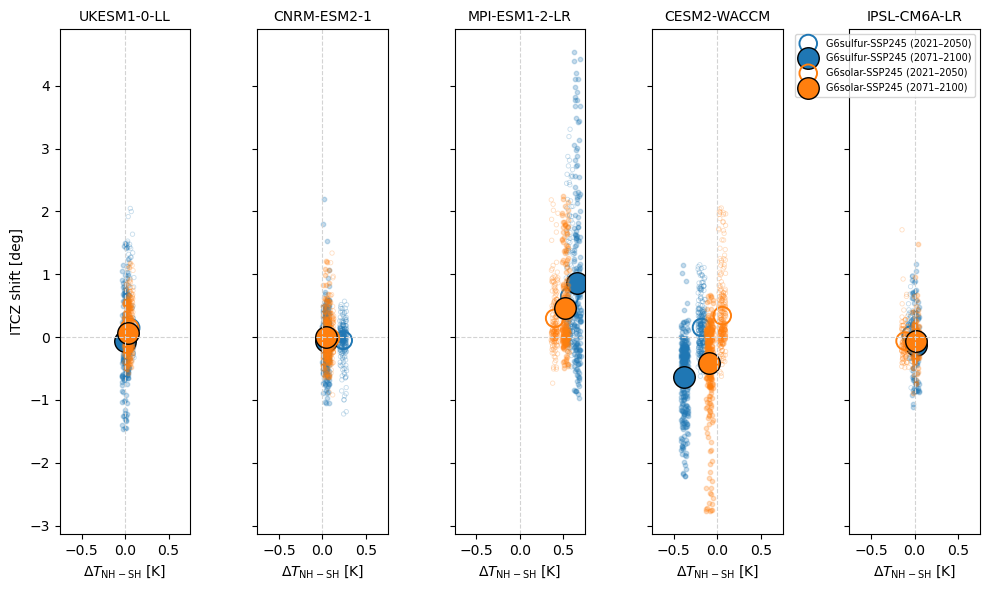

In [10]:
import matplotlib.pyplot as plt
import numpy as np

experiments = ["G6sulfur-SSP245", "G6solar-SSP245"]
models = list(MODELS.keys())

n_models = len(models)
fig, axes = plt.subplots(
    nrows=1,
    ncols=n_models,
    figsize=(2*n_models, 6),
    sharey=True
)

if n_models == 1:
    axes = [axes]

x_spread = 0.04
colors = {"G6sulfur-SSP245": "C0", "G6solar-SSP245": "C1"}

for ax, model in zip(axes, models):

    for exp in experiments:

        # =========================
        # EARLY: 2021–2050
        # =========================
        x_early = TS_hemispheric_2021_2050.loc[exp, model].values

        itcz_mean_early = ITCZ_shift_all_2021_2050[model][exp]["mean"].values
        itcz_by_lon_early = ITCZ_shift_all_2021_2050[model][exp]["by_lon"].values

        jitter = np.random.uniform(-x_spread, x_spread, size=itcz_by_lon_early.size)

        ax.scatter(
            x_early + jitter,
            itcz_by_lon_early,
            facecolors='none',
            edgecolors=colors[exp],
            alpha=0.25,
            s=10,
            linewidth=0.6,
            label="_nolegend_"
        )

        ax.scatter(
            x_early,
            itcz_mean_early,
            facecolors='none',
            edgecolors=colors[exp],
            s=160,
            linewidth=1.4,
            label=f"{exp} (2021–2050)"
        )

        # =========================
        # LATE: 2071–2100
        # =========================
        x_late = TS_hemispheric_2071_2100.loc[exp, model].values

        itcz_mean_late = ITCZ_shift_all_2071_2100[model][exp]["mean"].values
        itcz_by_lon_late = ITCZ_shift_all_2071_2100[model][exp]["by_lon"].values

        jitter = np.random.uniform(-x_spread, x_spread, size=itcz_by_lon_late.size)

        ax.scatter(
            x_late + jitter,
            itcz_by_lon_late,
            color=colors[exp],
            alpha=0.25,
            s=10,
            label="_nolegend_"
        )

        ax.scatter(
            x_late,
            itcz_mean_late,
            color=colors[exp],
            edgecolor='k',
            s=240,
            label=f"{exp} (2071–2100)"
        )

    # Reference lines (only meaningful ones)
    ax.axvline(0, color='lightgray', linestyle='--', linewidth=0.8)
    ax.axhline(0, color='lightgray', linestyle='--', linewidth=0.8)

    ax.set_xlim(-0.75, 0.75)
    ax.set_xlabel(r"$\Delta T_{\mathrm{NH-SH}}$ [K]")
    ax.set_title(model, fontsize=10)

axes[0].set_ylabel("ITCZ shift [deg]")

# Single legend (last panel)
handles, labels = axes[-1].get_legend_handles_labels()
axes[-1].legend(handles, labels, fontsize=7, loc="upper right")

plt.tight_layout()
plt.show()